<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/Medical_Cost_Predection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [249]:
!pip install optuna
!pip install xgboost
!pip install lightgbm

In [250]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
import optuna
import xgboost as xgb
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score



In [251]:
df=pd.read_csv("insurance.csv")

In [252]:
df.shape

(1338, 7)

In [253]:
target_col=df['charges']

In [254]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
435,60,male,33.110,3,no,southeast,13919.82290
636,19,female,24.510,1,no,northwest,2709.11190
1310,42,male,26.315,1,no,northwest,6940.90985
213,34,female,26.730,1,no,southeast,5002.78270
415,43,female,35.640,1,no,southeast,7345.72660


In [255]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [256]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [257]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [258]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**EDA**

In [259]:
df.corr(numeric_only=True)['charges'].sort_values(ascending=False)

,charges
charges,1.000000
age,0.299008
bmi,0.198341
children,0.067998


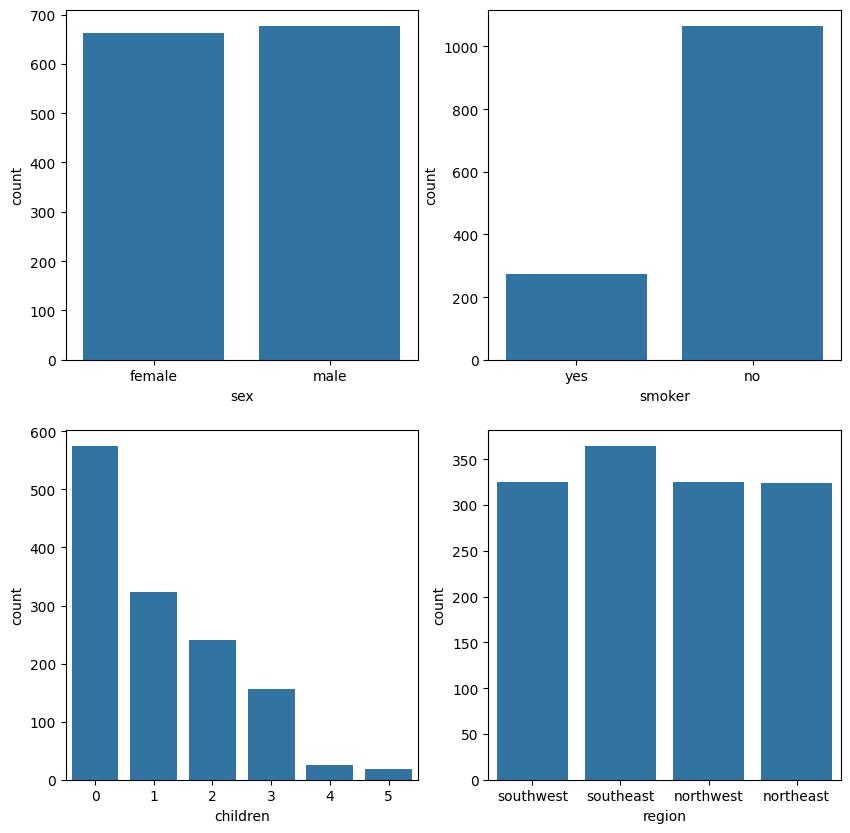

In [260]:
# create a subplot to display countplot for categorical features
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
sns.countplot(x=df['sex'])
plt.subplot(2, 2, 2)
sns.countplot(x=df['smoker'])
plt.subplot(2, 2, 3)
sns.countplot(x=df['children'])
plt.subplot(2, 2, 4)
sns.countplot(x=df['region'])
plt.show()

<Axes: xlabel='bmi', ylabel='Count'>

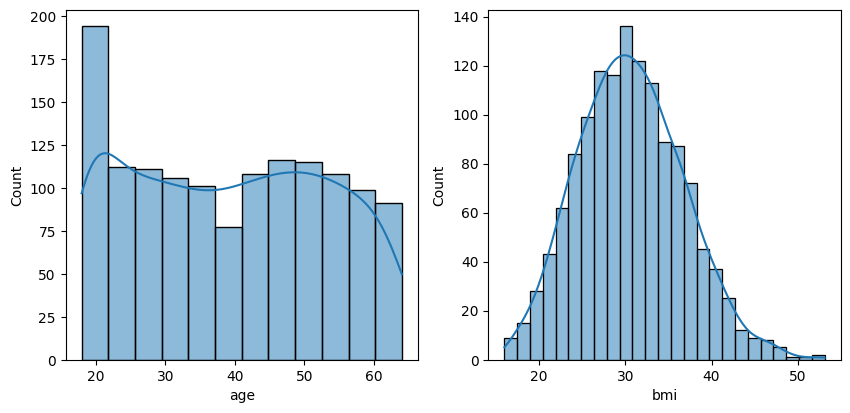

In [261]:
# Create subplots to display distribution plots for numeric columns in 'num_cols'
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
sns.histplot(df['age'], kde=True)
plt.subplot(2, 2, 2)
sns.histplot(df['bmi'], kde=True)

In [262]:
# droping the age column as it doesnot contribute to our output
# 1. Separate features (X) and target (y)
X = df.drop(columns=['charges','region','sex'])
y = target_col
X["smoker_bmi"] = (X["smoker"] == "yes").astype(int) * X["bmi"]
X["smoker_age"] = (X["smoker"] == "yes").astype(int) * X["age"]

**preprocessing**

In [263]:
# 2. Identify column types automatically
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numerical features: {num_cols}")
print(f"Categorical features: {cat_cols}")

Numerical features: ['age', 'bmi', 'children', 'smoker_bmi', 'smoker_age']
Categorical features: ['smoker']


In [264]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

num_transformer = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

cat_transformer = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
    ]
)






In [265]:
# 4. Process the data
X_processed = preprocessor.fit_transform(X)


# 5. Get the new processed feature names
new_feature_names = num_cols + list(
    preprocessor.named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)
X_processed_df = pd.DataFrame(X_processed, columns=new_feature_names)

In [266]:
X_processed_df

,age,bmi,children,smoker_bmi,smoker_age,smoker_no,smoker_yes
0,-1.438764,-0.453320,-0.908614,1.699463,0.66280,0.0,1.0
1,-1.509965,0.509621,-0.078767,-0.494516,-0.47041,1.0,0.0
2,-0.797954,0.383307,1.580926,-0.494516,-0.47041,1.0,0.0
3,-0.441948,-1.305531,-0.908614,-0.494516,-0.47041,1.0,0.0
4,-0.513149,-0.292556,-0.908614,-0.494516,-0.47041,1.0,0.0
...,...,...,...,...,...,...,...
1333,0.768473,0.050297,1.580926,-0.494516,-0.47041,1.0,0.0
1334,-1.509965,0.206139,-0.908614,-0.494516,-0.47041,1.0,0.0
1335,-1.509965,1.014878,-0.908614,-0.494516,-0.47041,1.0,0.0
1336,-1.296362,-0.797813,-0.908614,-0.494516,-0.47041,1.0,0.0


**Modeling**

In [267]:
# split the dataset into test and train
# 6. Split into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df, y, test_size=0.2, random_state=42
)

In [268]:
import lightgbm as lgb
import optuna
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score


def objective(trial, X, y):
    # Suggest the model architecture itself as a hyperparameter
    model_type = trial.suggest_categorical(
        "model", ["xgboost", "lightgbm", "randomforest"]
    )

    # Define model specific hyperparameters
    if model_type == "xgboost":
        params = {
            "n_estimators": trial.suggest_int("xgb_n_estimators", 100, 1000),
            "max_depth": trial.suggest_int("xgb_max_depth", 10, 50),
            "learning_rate": trial.suggest_float("xgb_learning_rate", 0.001, 0.01),
            "subsample": trial.suggest_float("xgb_subsample", 0.6, 1.0),
            "n_jobs": -1,
            "random_state": 42,
        }
        model = xgb.XGBRegressor(**params)

    elif model_type == "lightgbm":
        params = {
            "n_estimators": trial.suggest_int("lgb_n_estimators", 50, 300),
            "max_depth": trial.suggest_int("lgb_max_depth", 3, 9),
            "learning_rate": trial.suggest_float(
                "lgb_learning_rate", 0.01, 0.2, log=True
            ),
            "num_leaves": trial.suggest_int("lgb_num_leaves", 10, 100),
            "n_jobs": -1,
            "random_state": 42,
            "verbose": -1,
        }
        model = lgb.LGBMRegressor(**params)

    elif model_type == "randomforest":
        params = {
            "n_estimators": trial.suggest_int("rf_n_estimators", 50, 200),
            "max_depth": trial.suggest_int("rf_max_depth", 5, 20),
            "min_samples_split": trial.suggest_int("rf_min_samples_split", 2, 10),
            "n_jobs": -1,
            "random_state": 42,
        }
        # Fixed: Imported directly from sklearn instead of lgb
        model = RandomForestRegressor(**params)

    # Evaluate using cross-validation
    scores = cross_val_score(
        model, X, y, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1
    )
    mae = -scores.mean()

    return mae



In [269]:

# --- Running the Study ---
study = optuna.create_study(direction="minimize")

# Correct lambda setup: only pass X_train and y_train alongside the trial object
study.optimize(
    lambda trial: objective(trial, X_train, y_train), n_trials=100, n_jobs=1
)

print("Best model and parameters:", study.best_params)
print("Best MAE:", study.best_value)


[I 2026-08-22 05:12:48,606] A new study created in memory with name: no-name-e897296c-90f2-4354-acd4-2712dd07fd71
[I 2026-08-22 05:12:59,614] Trial 0 finished with value: 2810.6425274655767 and parameters: {'model': 'lightgbm', 'lgb_n_estimators': 193, 'lgb_max_depth': 9, 'lgb_learning_rate': 0.015431569584313265, 'lgb_num_leaves': 68}. Best is trial 0 with value: 2810.6425274655767.
[I 2026-08-22 05:13:16,111] Trial 1 finished with value: 2970.954081819364 and parameters: {'model': 'xgboost', 'xgb_n_estimators': 647, 'xgb_max_depth': 40, 'xgb_learning_rate': 0.003972448853405223, 'xgb_subsample': 0.6470734797826568}. Best is trial 0 with value: 2810.6425274655767.
[I 2026-08-22 05:13:18,275] Trial 2 finished with value: 3562.5126523212757 and parameters: {'model': 'lightgbm', 'lgb_n_estimators': 129, 'lgb_max_depth': 4, 'lgb_learning_rate': 0.012488616336017475, 'lgb_num_leaves': 43}. Best is trial 0 with value: 2810.6425274655767.
[I 2026-08-22 05:13:23,729] Trial 3 finished with val

Best model and parameters: {'model': 'randomforest', 'rf_n_estimators': 62, 'rf_max_depth': 7, 'rf_min_samples_split': 3}
Best MAE: 2604.6769249353956


In [273]:
study.best_params

{'model': 'randomforest',
 'rf_n_estimators': 62,
 'rf_max_depth': 7,
 'rf_min_samples_split': 3}

In [274]:
finalmodel=RandomForestRegressor(n_estimators=62,max_depth=7,min_samples_split=3,n_jobs=-1,random_state=42)
y_train_log = np.log1p(y_train)
# train model on y_train_log
finalmodel.fit(X_train, y_train_log)
# then when predicting:
y_pred = np.expm1(finalmodel.predict(X_test))



In [275]:
# r2 and rmse
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 19604256.58114706
RMSE: 4427.669429976346
R2: 0.873723563517903
